# &nbsp;&nbsp;ArcGIS Python API
### &nbsp;&nbsp;&nbsp;for Analysts and Data Scientists
<br/>
<br/>


###  &nbsp;&nbsp;                Rohit Singh
 <img src="ScienceOfWhere2.PNG"/>


In [163]:
print('Hello, world!')

Hello, world!


# ArcGIS Python API
## A quick introduction

* Python API to your Web GIS

* Powerful, modern and easy to use

* Implemented using REST + local capabilities

# API Overview
## A Pythonic platform for geospatial analysis
<img src="api-overview.png" />

# It all starts with your GIS

In [1]:
from arcgis.gis import GIS
from getpass import getpass  

In [2]:
gis = GIS('https://deldev.maps.arcgis.com', 'deldev', 'P@ssw0rd@123')

In [1]:
gis = GIS('https://deldev.maps.arcgis.com', 'deldev', getpass())

········


In [4]:
username = 'djohnsonRA'
password = 'M62evVB12pl'

In [5]:
enterprise = GIS('https://dev004543.esri.com/arcgis', username, password)

# Search for content

In [6]:
items = gis.content.search('San Diego')

<Item title:"San Diego Trolley stations" type:Feature Collection owner:deldev>
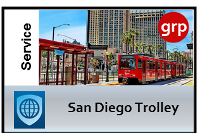

<Item title:"Some Places to Go in San Diego, California" type:Web Map owner:deldev>
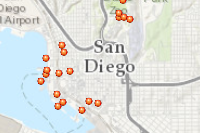

<Item title:"Top 10 San Diego" type:Feature Collection owner:deldev>
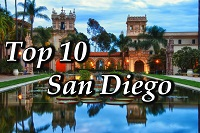

In [7]:
for item in items:
    display(item)

In [8]:
trolley_stations = items[0]
sd_attractions = items[2]

# Visualize layers on map widget

In [164]:
sdmap = gis.map('San Diego', zoomlevel=14)
sdmap

In [170]:
sdmap.add_layer(sd_attractions)

In [171]:
sdmap.add_layer(trolley_stations)

<img src='SpatialAnalysis.png'/>

## Which attractions are near trolley stations?

In [15]:
arcgis.env.active_gis = gis

In [12]:
from arcgis.features.use_proximity import create_buffers
from arcgis.features.manage_data import overlay_layers

In [16]:
places_to_see = overlay_layers(input_layer=sd_attractions,
                               overlay_layer=create_buffers(trolley_stations,
                                                            [0.5], units='Miles'))

In [19]:
my_map = gis.map('San Diego', zoomlevel=14)
display(my_map)
my_map.add_layer(places_to_see)

## Analysis results as a table

In [21]:
df = places_to_see.query().df
df = df[['NAME', 'Title']]
df

,NAME,Title
0,Welcome to San Diego!,COUNTY CENTER/LITTLE ITALY TROLLEY STATION
1,Convention Center skywalk &amp; stairs,CONVENTION CENTER TROLLEY STATION
2,Gaslamp Quarter,12TH AND MARKET TROLLEY STATION
3,Petco Park,12TH AND MARKET TROLLEY STATION
4,Embarcadero Marina Park North,SEAPORT VILLAGE TROLLEY STATION
5,Embarcadero bayside path,SEAPORT VILLAGE TROLLEY STATION
6,The Headquarters at Seaport District,AMERICA PLAZA TROLLEY STATION
7,USS Midway Museum,AMERICA PLAZA TROLLEY STATION
8,Ferry to Coronado,COUNTY CENTER/LITTLE ITALY TROLLEY STATION
9,San Diego Bay cruise,COUNTY CENTER/LITTLE ITALY TROLLEY STATION


# Querying Features

<Item title:"USA Counties" type:Feature Service owner:esri_dm>
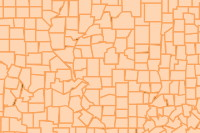

In [22]:
counties_item = gis.content.search('USA Counties', 'Feature Layer', 
                                   outside_org=True)[0]
counties_item

In [23]:
counties = counties_item.layers[0]

In [24]:
ca_counties = counties.query(where="STATE_NAME='California'")

## Spatial dataframe

In [25]:
counties_df = ca_counties.df
counties_df

,AGE_10_14,AGE_15_19,AGE_20_24,AGE_25_34,AGE_35_44,AGE_45_54,AGE_55_64,AGE_5_9,AGE_65_74,AGE_75_84,...,POP10_SQMI,POP12_SQMI,POP2010,POP2012,RENTER_OCC,SQMI,STATE_NAME,VACANT,WHITE,SHAPE
0,68473,72493,65339,122046,108500,108479,77285,68694,43502,23473,...,102.9,104.282870,839631,851089,101782,8161.35,California,29757,499766,"{'rings': [[[-13119789.4732166, 4272899.442060..."
1,11324,11356,13158,25589,21878,20282,12924,11564,6844,3809,...,109.9,111.427421,152982,155039,18904,1391.39,California,2634,83027,"{'rings': [[[-13342775.4280577, 4356085.351079..."
2,3888,4190,3362,6603,7095,10255,10625,3574,6553,3502,...,48.6,49.082334,64665,65253,9076,1329.46,California,8944,52033,"{'rings': [[[-13667224.3154792, 4696180.986610..."
3,1853,2107,2831,6337,5513,5447,4113,1595,1984,1041,...,7.4,7.422856,34895,35039,3468,4720.42,California,2652,25532,"{'rings': [[[-13418482.3589672, 5039533.376017..."
4,678845,753630,752788,1475731,1430326,1368947,1013156,633690,568470,345603,...,2402.3,2423.264150,9818605,9904341,1696455,4087.19,California,203872,4936599,"{'rings': [[[-13149469.25, 3995666.625], [-131..."
5,11755,12224,11032,20562,19167,19291,15833,11756,9868,5468,...,70.1,71.065672,150865,153025,15591,2153.29,California,5823,94456,"{'rings': [[[-13337486.1875, 4418437.5625], [-..."
6,14241,12798,10308,24836,36478,42055,40088,15481,23211,12425,...,480.2,486.100489,252409,255509,38573,525.63,California,8004,201963,"{'rings': [[[-13691681.78125, 4611910], [-1369..."
7,987,1026,827,1651,1828,3232,3283,821,2253,1186,...,12.5,12.613887,18251,18455,2466,1463.07,California,2495,16103,"{'rings': [[[-13364133.625, 4464660.5], [-1336..."
8,5390,5613,4874,10704,10268,12476,14417,5259,7556,3983,...,25.0,25.083070,87841,88094,14344,3512.09,California,5378,67218,"{'rings': [[[-13752510.6332503, 4689126.202854..."
9,22115,24451,20195,35060,31967,31007,22645,22167,13205,7717,...,129.4,129.897434,255793,256841,34446,1977.26,California,8056,148381,"{'rings': [[[-13401606.6535612, 4527640.672262..."


## Pandorable (attribute and spatial) selections

In [26]:
sd_county = counties_df[counties_df.NAME == 'San Diego']

In [27]:
# Attribute query
sd_county.POP2012.iloc[0]

3137431

In [28]:
# query the shape of San Diego county and set it's spatial reference
sd_geom = sd_county.SHAPE.iloc[0]
sd_geom.spatial_reference = counties.container.properties.spatialReference

In [173]:
m = gis.map('San Diego', zoomlevel=7)
m.draw(sd_geom)
m

## Exploratory data analysis

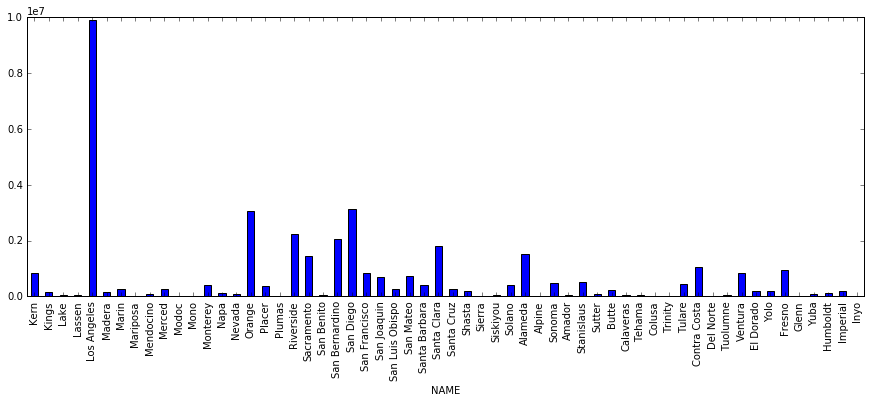

In [174]:
%matplotlib inline
plotdf = counties_df.set_index('NAME')
plotdf.POP2012.plot(kind='bar', x='NAME', figsize=(15,5))

# Smart Mapping

In [165]:
ca_map = gis.map("California")
ca_map

In [175]:
ca_map.add_layer(counties, {
                             "definition_expression": "STATE_NAME='California'",
                             "renderer": "ClassedColorRenderer",
                             "field_name": "POP2012"
                            })

<img src="GeoAnalytics.png"/>

# Analyse crimes in Houston, TX
<img src="Houston/hpd.png" width="750"/>

In [43]:
houston_gis = GIS('https://dev003246.esri.com/portal', USERNAME, PASSWORD)
#gis = houston_gis

# Attach data

In [ ]:
datastores = arcgis.geoanalytics.get_datastores()
datastores.add_bigdata('Houston_crime_yearly', 
                       r'\\teton\atma_shared\datasets\HoustonCrime')

In [52]:
houston_yearly = houston_gis.content.search('Houston_crime_yearly',
                                            'big data file share')[0]
houston_yearly

<Item title:"bigDataFileShares_Houston_crime_yearly" type:Big Data File Share owner:admin>

In [147]:
houston_yearly.layers

[<Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2010">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2011">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2012">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2013">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2014">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2015">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataSt

# Invoke batch analytics

In [46]:
from ipywidgets import *
from arcgis.geoanalytics.analyze_patterns import find_hot_spots
arcgis.env.process_spatial_reference=32611
arcgis.env.verbose = False
houston = arcgis.geocoding.geocode('Houston, TX')[0]

In [ ]:
for category in df.Category.unique()[:-1]: 
    lyrid = 0
    for year in range(2010, 2017):
        output_name='Houston_' + category.replace(' ', '_') + '_Hotspot_' + str(year)
        print('Generating ' + output_name)
        layer = houston_yearly.layers[lyrid]
        layer.filter = "Category='{}'".format(category)
        
        find_hot_spots(layer, bin_size=0.5, bin_size_unit='Miles', 
                       neighborhood_distance=1, neighborhood_distance_unit='Miles', 
                       output_name=output_name)
        
        lyrid = lyrid + 1

# View results
## Compare Hot Spots across crime categories

In [48]:
hotmap1 = houston_gis.map(houston, 10)
hotmap1.add_layer(houston_gis.content.search('Houston_Burglary_Hotspot_2016')[0])
hotmap2 = houston_gis.map(houston, 10)
hotmap2.add_layer(houston_gis.content.search('Houston_Auto_Theft_Hotspot_2016')[0])

hotmap1.layout=Layout(flex='1 1', padding='3px')
hotmap2.layout=Layout(flex='1 1', padding='3px')

items_layout = Layout(flex='1 1 auto', width='auto')

In [146]:
display(HBox([hotmap1, hotmap2]))
display(HBox(children=[Button(description='Burglary hot spots in 2016', layout=items_layout, button_style='danger'),
                       Button(description='Auto theft hot spots in 2016', layout=items_layout, button_style='danger')],
             layout=Layout(width='100%')))

## Compare Hot Spots over time

In [50]:
maps = []
labels = []
items_layout = Layout(flex='1 1 auto', width='auto')
layout=Layout(height='300px')

In [51]:
for year in range(2014, 2017):
    layer = houston_gis.content.search('Houston_Auto_Theft_Hotspot_' + str(year))[0]
    hotspotmap = houston_gis.map(houston)
    hotspotmap.add_layer(layer)
    hotspotmap.layout=Layout(flex='1 1', padding='3px')
    maps.append(hotspotmap)
    hotspotmap.basemap='gray'
    labels.append(Button(description='Auto theft hot spots in ' + str(year), 
                         layout=items_layout, button_style='danger'))
    
display(HBox([maps[0], maps[1], maps[2]], layout=layout))
display(HBox(children=labels, layout=Layout(width='100%')))

<img src='RasterAnalysis.png'/>

# Use Landsat Imagery

In [55]:
landsat_item = gis.content.search('"Landsat Multispectral"', 
                                  'Imagery Layer', outside_org=True)[0]

<Item title:"Multispectral Landsat" type:Image Service owner:esri>
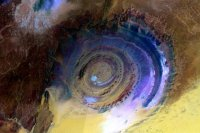

In [56]:
landsat_item

In [57]:
landsat = landsat_item.layers[0]

## Visualize imagery layers

In [166]:
imagery_map = gis.map('San Diego, CA', zoomlevel=12)
imagery_map.add_layer(landsat)
imagery_map

## Code: Plot spectral profile at clicked location

In [58]:
import pandas as pd
pd.DataFrame(landsat.key_properties()['BandProperties'])

,BandIndex,BandName,DatasetTag,WavelengthMax,WavelengthMin
0,0,CoastalAerosol,MS,450,430
1,1,Blue,MS,510,450
2,2,Green,MS,590,530
3,3,Red,MS,670,640
4,4,NearInfrared,MS,880,850
5,5,ShortWaveInfrared_1,MS,1650,1570
6,6,ShortWaveInfrared_2,MS,2290,2110
7,7,Cirrus,MS,1380,1360


In [167]:
from bokeh.models import Range1d
from bokeh.plotting import figure, show, output_notebook
from IPython.display import clear_output

output_notebook()

def handle_click(m, pt):
    m.draw(pt)
    
    samples = landsat.get_samples(pt, pixel_size=30)
    values = samples[0]['value']
    
    x = ['1','2', '3', '4', '5', '6', '7', '8']
    y = [float(int(s)/100000) for s in values.split(' ')]
    
    p = figure(title="Spectral Profile", x_axis_label='Spectral Bands', 
               y_axis_label='Data Values', width=600, height=300)
    p.line(x, y, legend="Selected Point", line_color="red", line_width=2)
    p.circle(x, y, line_color="red", fill_color="white", size=8)
    p.set(y_range=Range1d(0, 1.0))
    
    clear_output()
    show(p)

Loading BokehJS ...

In [168]:
click_map = gis.map('San Diego, CA', zoomlevel=12)
click_map.add_layer(landsat)
click_map.on_click(handle_click)

## Demo: Plot spectral profile at clicked location

In [169]:
click_map

## Dynamic raster processing

In [100]:
dynamic_map = gis.map('San Diego, CA', zoomlevel=12)
dynamic_map.add_layer(landsat)
dynamic_map

In [91]:
from arcgis.raster.functions import *

In [176]:
import time

for rasterfunc in landsat.properties.rasterFunctionInfos:
    clear_output()
    print(rasterfunc.name)
    
    dynamic_map.add_layer(apply(landsat, rasterfunc.name))
    time.sleep(2)

None


### Custom raster processing using Raster Functions

<img src="raster-functions2.png"/>

## Raster function chains

In [74]:
zurichmap = gis.map('Zurich, Switzerland')
zurichmap

In [75]:
land_water_boundary = stretch(extract_band(landsat, [4, 5, 3]),
                              stretch_type='percentclip', 
                              min_percent=1, max_percent=1, gamma=[1, 1, 1], 
                              dra=True)

In [76]:
zurichmap.add_layer(land_water_boundary)

## Weighted overlay analysis

### Where do I take kids camping?
Identify areas that "feel" remote, but are still relatively easy to access.
* Out in nature
* Not too high in elevation
* Not too steep

<img src="map-algebra.png"/>

## Function chain for weighted overlay analysis

<img src="rft-woa.png"/>

In [27]:
# portal = GIS('https://dev004543.esri.com/arcgis', USERNAME, PASSWORD)
portal = GIS('https://dev004543.esri.com/arcgis', 'djohnsonRA', "M62evVB12pl")

## Inputs
### Elevation raster

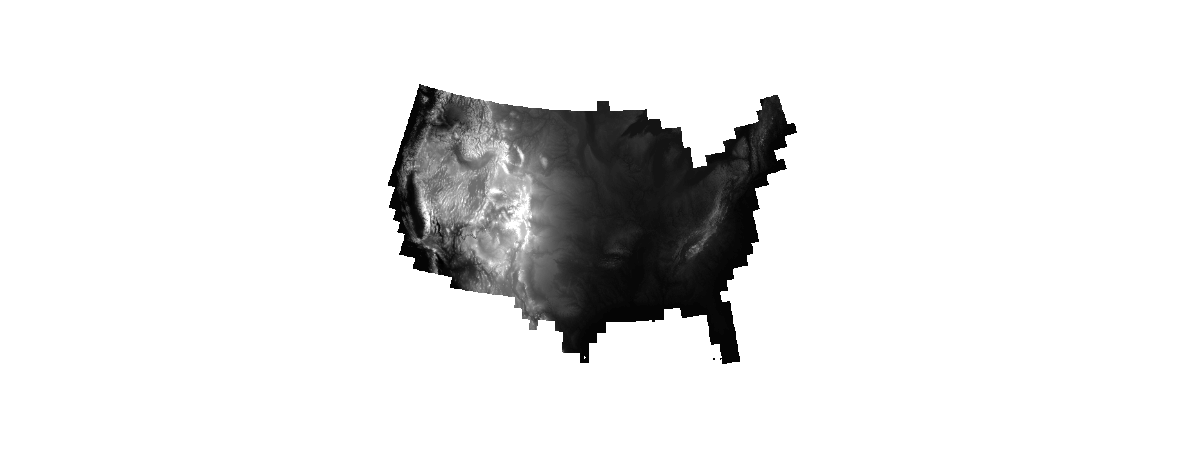

In [105]:
# Digital elevation model for the US

item_dem = enterprise.content.search('USGS NED 30m')[0]
lyr_dem = item_dem.layers[0]
lyr_dem

### Human modified index

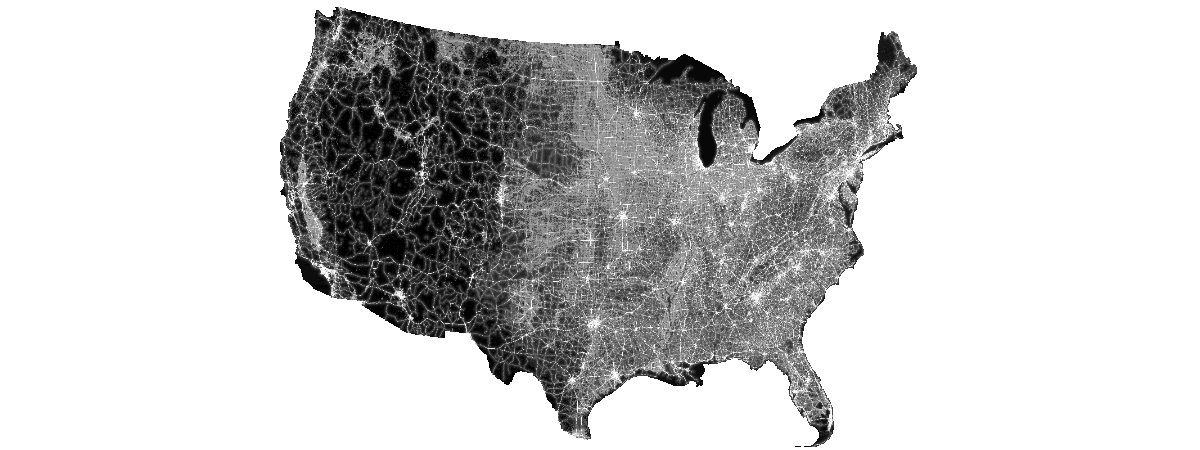

In [103]:
# Human Modified Index imagery layer
# This dataset is based on research on the degree of human modification to
# the landscape, on a scale of 0 - 1, where 0.0 indicates unmodified natural
# landscape and 1.0 indicates the landscape is completely modified by human activity.

item_hmi = enterprise.content.search('Human_Modified_Index')[0]
lyr_hmi = item_hmi.layers[0]
lyr_hmi

## Set area of interest as layer's extent

In [108]:
# geocode the area of interest
from arcgis.geocoding import geocode

sd_county = geocode('San Diego County', 
                    out_sr=lyr_dem.properties.spatialReference)[0]

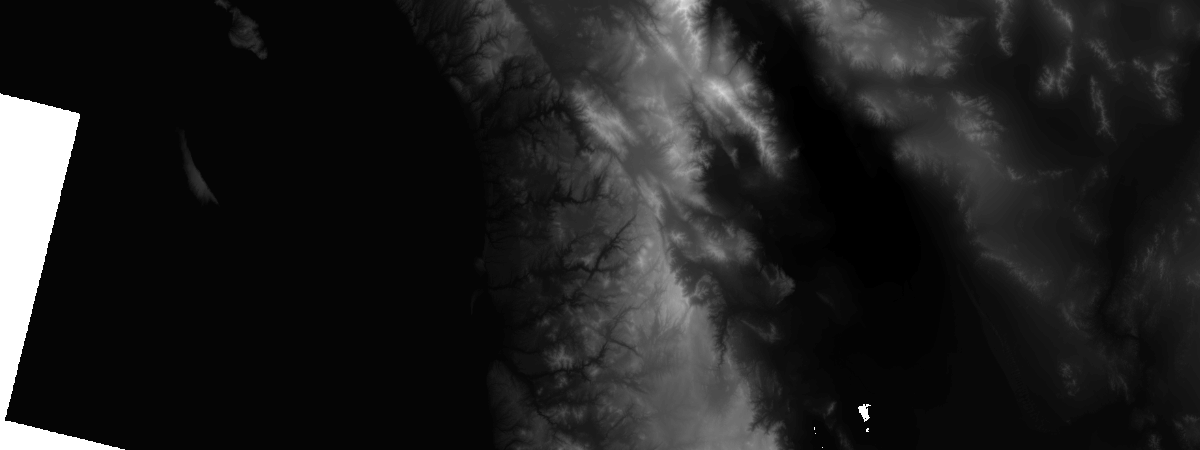

In [109]:
# set the area of interest as the layer's extent
lyr_dem.extent = sd_county['extent']
lyr_dem

### Interactive raster processing in Jupyter Notebook

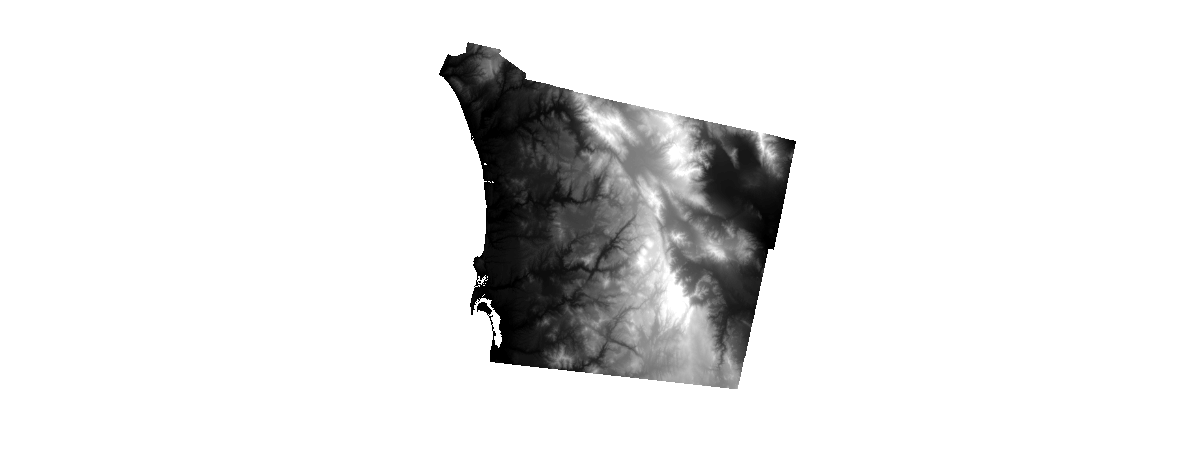

In [113]:
clipped_elev = clip(lyr_dem, sd_geom)
clipped_elev

In [115]:
# Create a colormap for rendering the analysis results.

clrmap=  [[1,  38, 115,0],[2,  86, 148,0],[3,  0x8B, 0xB5,0],[4,  0xC5, 0xDB,0],
         [5, 255, 255, 0],[6,  0xFF, 0xC3,0],[7, 0xFA, 0x8E, 0],[8,  0xF2, 0x55,0],
         [9, 0xE6, 0, 0]]

## Chaining raster functions

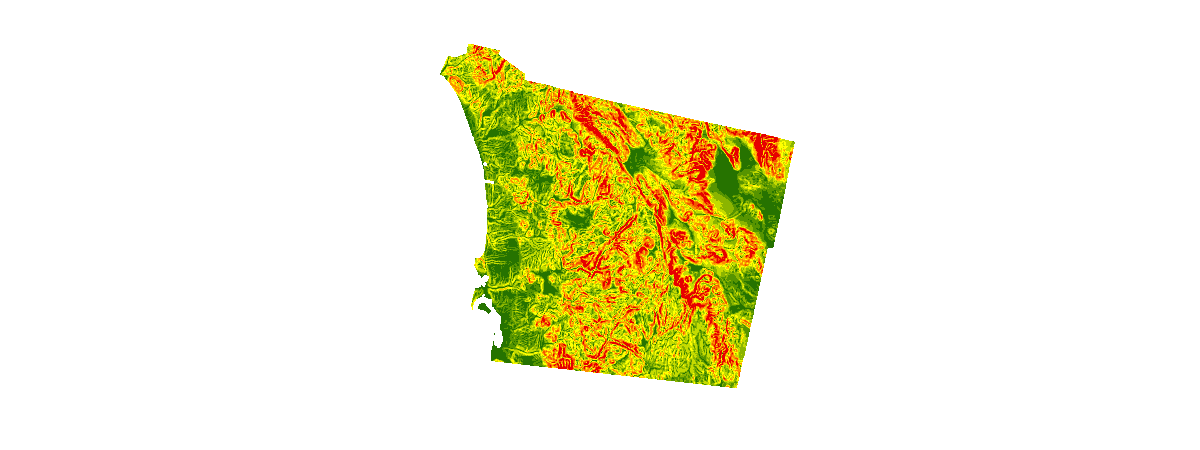

In [160]:
colormap(remap(slope(clipped_elev, 
                     slope_type='DEGREE', 
                     z_factor=1),
               input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
               output_values=[1,2,3,4,5,6,7,8,9]),
         colormap=clrmap)

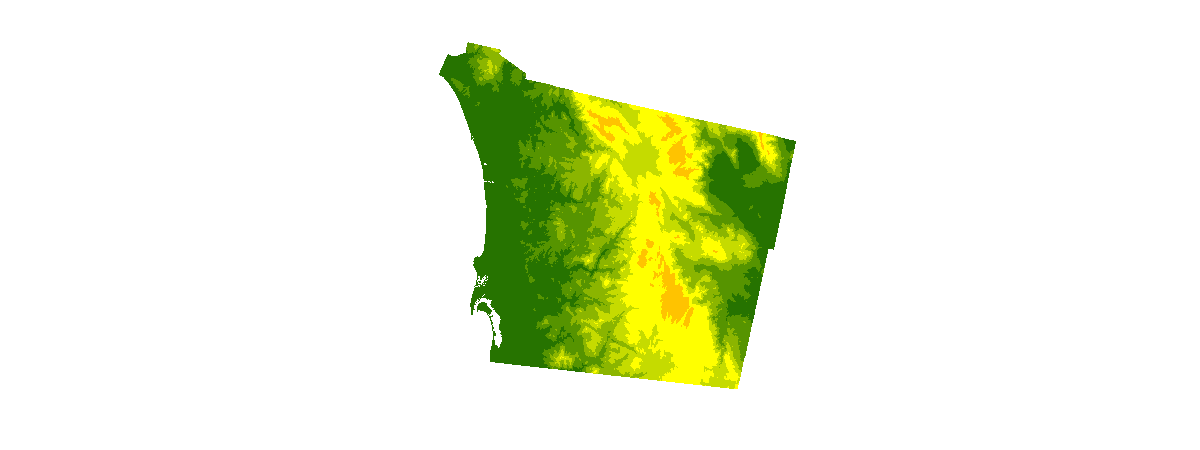

In [40]:
colormap(remap(clip(lyr_dem, sd_geom),  # Elevation 
                    input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 1500,2000, 2000,2500, 2500,3000, 3000,5000],
                    output_values=[1,2,3,4,5,6,7,8,9]) ,
        colormap=clrmap)

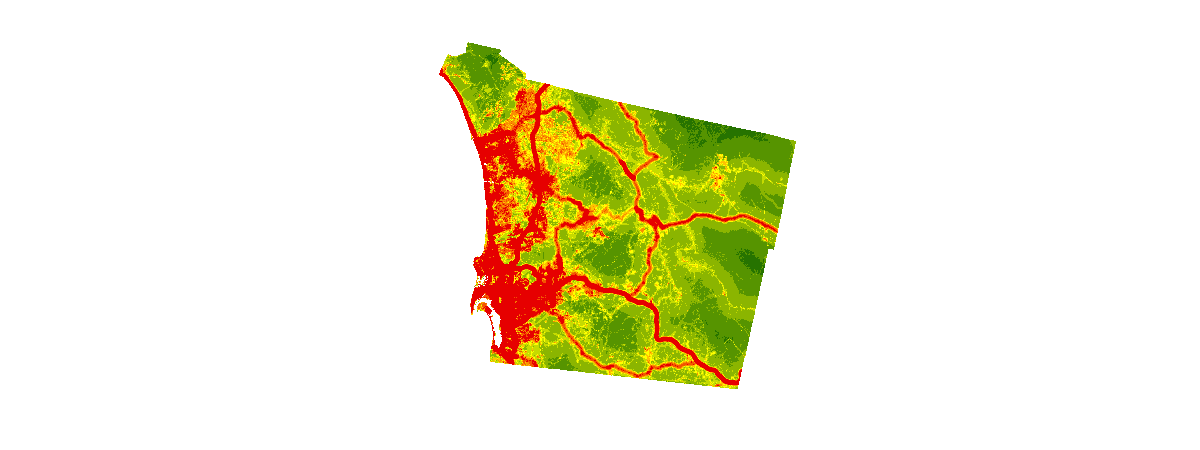

In [117]:
lyr_hmi.extent = sd_county['extent']
colormap(remap(clip(lyr_hmi, sd_geom), # Human modified index 
                     input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                     output_values=[1,2,3,4,5,6,7,8,9]),
        colormap=clrmap)

## Weighted overlay analysis using Map Algebra

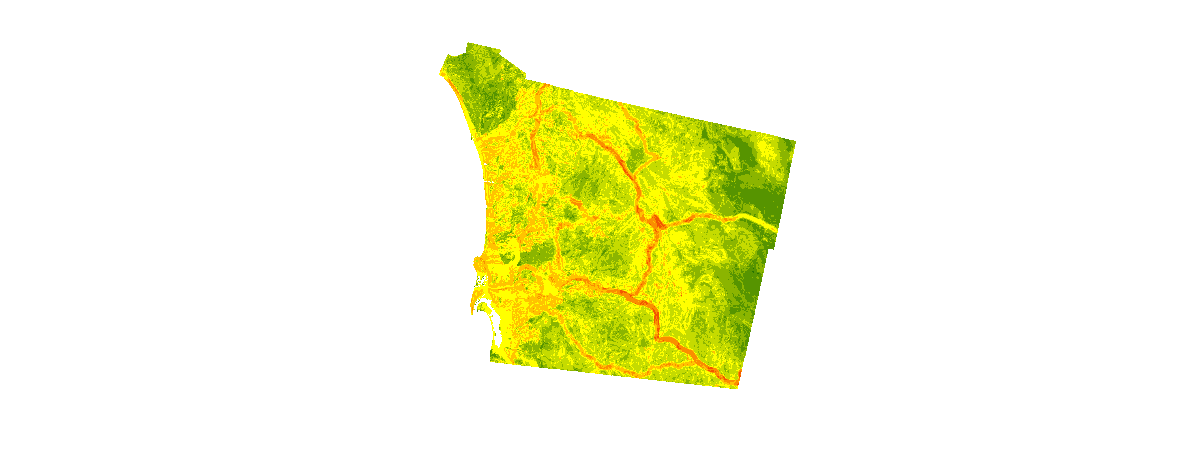

In [118]:
weighted_overlay = colormap(
    
        0.25 * remap(clip(lyr_dem, sd_geom),  # Elevation 
                    input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 1500,2000, 2000,2500, 2500,3000, 3000,5000],
                    output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        0.25 * remap(clip(slope(lyr_dem, slope_type='DEGREE', z_factor=1), sd_geom),
                     input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
                     output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        0.5 * remap(clip(lyr_hmi, sd_geom), # Human modified index 
                     input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                     output_values=[1,2,3,4,5,6,7,8,9]),
        colormap=clrmap)
weighted_overlay

## Visualize results using map widget

In [120]:
surface_map = gis.map('San Diego County, CA')
surface_map.add_layer(weighted_overlay)
surface_map

In [ ]:
imagery_map = gis.map('San Diego County, CA')
imagery_map.add_layer(weighted_overlay)
imagery_map

<img src="where-do-i-hike-map-widget-sd.png"/>

## Persist results as an imagery layer

In [63]:
# Generate a persistent result at source resolution using Raster Analytics
resultlyr = weighted_overlay.save('SanDiegoCounty_Analysis')

In [45]:
resultlyr = enterprise.content.search('SanDiegoCounty_Analysis')[0]

In [46]:
resultlyr

<Item title:"SanDiegoCounty_Analysis" type:Image Service owner:djohnsonRA>

## Results: finding solitude by applying GIS

<img src="race.png" />

# Cross Country Mobility

<img src="ccm_rft.png"/>

# Generate cost surface 
## Use function chain authored in ArcGIS Pro

In [49]:
enterprise_b = GIS('https://dev004546.esri.com/portal', 'rsinghRA', 'rsinghRA1') 

In [47]:
with open("CCM_CostRnR.rft.xml", "r", encoding='utf-8-sig') as rft:
    raster_fn = rft.read()

In [ ]:
from arcgis.raster.analytics import generate_raster

surface = generate_raster(raster_fn, output_name='CCM_Cost_Surface')

In [123]:
surface = enterprise_b.content.search('title:CCM_Cost_Surface', 'Imagery Layer')[0]

In [51]:
surface

<Item title:"CCM_Cost_Surface" type:Image Service owner:rsinghRA>

# Generate least cost paths
## Draw map with origin locations

In [121]:
enterprise_b = GIS('https://dev004546.esri.com/portal', 'rsinghRA', 'rsinghRA1')

In [125]:
tank_symbol = {
  "type" : "esriPMS", 
  "url" : "http://static.arcgis.com/images/Symbols/Transportation/Tank.png", 
  "contentType" : "image/png", 
  "width" : 19.5, 
  "height" : 19.5, 
  "angle" : 0, 
  "xoffset" : 0, 
  "yoffset" : 0
}
finish_symbol = {"angle":0,"xoffset":12,"yoffset":12,"type":"esriPMS","url":"http://static.arcgis.com/images/Symbols/Basic/CheckeredFlag.png","contentType":"image/png","width":24,"height":24}

In [126]:
from arcgis.features import FeatureSet, Feature
arcgis.env.out_spatial_reference = 4326

In [127]:
ramona = geocode("Ramona, CA", out_sr=102100)[0]
poway = geocode("Poway, CA", out_sr=102100)[0]
barona = geocode("Barona Reservation, CA", out_sr=102100)[0]

origins=FeatureSet([Feature(ramona['location']), 
                    Feature(poway['location']),
                    Feature(barona['location'])])

<img src='GeoProcessing.png'/>

## Use Geoprocessing tool 
## Generate least cost paths to clicked location

In [128]:
from arcgis.geoprocessing import import_toolbox

ccmurl='https://maps.esri.com/apl3/rest/services/LCP/LCP/GPServer/LeastCostPath'
ccm = import_toolbox(ccmurl)

In [129]:
def find_path(m, pt):
    m.draw(pt, symbol=finish_symbol)
    paths = ccm.least_cost_path(destination=FeatureSet([Feature(pt)]), 
                                origins=origins)
    m.draw(paths)

## Finding least cost paths interactively

In [161]:
ccm_map = gis.map('San Vicente Reservoir', zoomlevel=10)
ccm_map.add_layer(surface, {'opacity':0.33})
ccm_map.on_click(find_path)
ccm_map

In [162]:
ramona = geocode("Ramona, CA")[0]
poway = geocode("Poway, CA")[0]
barona = geocode("Barona Reservation, CA")[0]

ccm_map.draw(ramona, symbol=tank_symbol)
ccm_map.draw(poway, symbol=tank_symbol)
ccm_map.draw(barona, symbol=tank_symbol)

<img src='Integration.png' />

# Integration with IBM Watson for Machine learning

* Integration with Watson (Geoprocessing?)
* Update Feature Layers / attachments
* Sequence Routing
* Intimate customers/prioritise repair, causality with hailstorms analysis?

<img src='ReleasePlan.png'/>

# Roadmap - API Enhancements
<br>
## Imagery layers and raster analysis
* Raster functions, colormap ramps, rendering
* Developer Guide
* Samples

## Spatial dataframe
* Cross platform fdgb support
* Cross platform geometry 

## Server API
* Publishing
* Portal administration

# Roadmap - Developer Experience
<br>

## Jupyter notebook integration
* 3D/Scene widget
* Notebook Integration (Data Science Experience with ArcGIS)
 * with ArcGIS Pro 2.1
 * ArcGIS Enterprise 10.6.1 
 * ArcGIS Online


<center>
 <img src="ScienceOfWhere.PNG"/>
 </center>